# Exercise 9 - CIFAR10 Challenge

## Group ID: 22
## Exercise day: Tuesday

## Task description:
In this exercise, you have all the freedom to come up with the best model, data augmentation, hyperparameters, loss function, etc. - essentially everything you have learned so far in the course - to achieve the highest possible accuracy on the CIFAR10 dataset.
You are allowed to use PyTorch functions for mechanisms which were covered in the previous exercises or lectures. But you are not allowed to use pre-trained models or any external dataset for training.
Also you have to provide a brief explanation of your model and all the decisions (hyperparameters, augmentation, etc.) you made to achieve the claimed accuracy.
To make the task more challenging, you have to train on an imbalanced traindataset.

Hint: For the final training process, you can use Google Colab which provides (time-restricted) free GPU resources.

## Submission:
- You have to submit a single .zip file containing this notebook and the weights of your model (model.pth).
- The total size of the .zip file must be less than 256MB. (absolute maximum, less is always better)
- The model file should be named model.pth.
- The test code at the end of your submitted notebook must run by only loading the provided model.pth file. We will not be able to run any training code.
- Upload the .zip via Ilias by clicking the **left** button called **"Datei hochladen"**(if you use the German version of Ilias). Please not use the right one, because Ilias will unzip your file in that case and can't handle .pth files.<br>
![](./upload.png)

## Evaluation:
The evaluation of the exercise is based on the achieved accuracy on the test dataset.
The baseline is 65% accuracy on the test dataset.

Note: The three best submissions will be awarded in the lecture with a small prize.

## Brief explanation of the model and the techniques used:
### Model Description
write here:

### Other Decisions you made
- Batch Size:
- Number of Epochs:
- ...


## Code:


### Imports and data loading

In [1]:
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset
import numpy as np
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

Files already downloaded and verified
Files already downloaded and verified


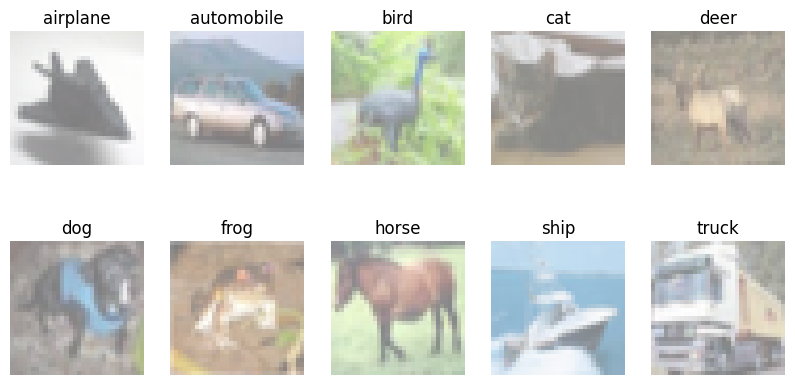

In [2]:
transform_train = transforms.Compose([transforms.ToTensor()])
transform_test = transforms.Compose([transforms.ToTensor()])

batch_size = 32

# Download and load the data
trainset = torchvision.datasets.CIFAR10(root='../../data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='../../data', train=False, download=True, transform=transform_test)

# Create imbalanced traindataset
num_samples_per_class = {k: (k + 1) * 500 for k in range(10)}
class_to_indices = {cls: np.where(np.array(trainset.targets) == cls)[0] for cls in range(10)}
imbalanced_indices = []
for cls, count in num_samples_per_class.items():
    indices = class_to_indices[cls][:count]  # Select the first `count` samples
    imbalanced_indices.extend(indices)
imbalanced_trainset = Subset(trainset, imbalanced_indices)

trainloader = torch.utils.data.DataLoader(imbalanced_trainset, batch_size=batch_size, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog",
           "horse", "ship", "truck"]

# get one image from each class
images = []
for i in range(10):
    for image, label in trainset:
        if label == i:
            images.append(image)
            break

# plot the images
fig, axs = plt.subplots(2, 5, figsize=(10, 5))
for i in range(10):
    ax = axs[i // 5, i % 5]
    ax.imshow(images[i].permute(1, 2, 0).numpy() / 2 + 0.5)
    ax.set_title(classes[i])
    ax.axis('off')
plt.show()


### Model

In [3]:
class ResidualBlock(nn.Module):
    def __init__(self, inchannel, outchannel, stride=1, p_l=0.0):
        super(ResidualBlock, self).__init__()
        self.p_l = p_l
        self.residual = nn.Sequential(
            nn.Conv2d(inchannel, outchannel, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(outchannel),
            nn.ReLU(inplace=True),
            nn.Conv2d(outchannel, outchannel, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(outchannel)
        )
        self.shortcut = nn.Sequential()
        if stride != 1 or inchannel != outchannel:
            self.shortcut = nn.Sequential(
                nn.Conv2d(inchannel, outchannel, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(outchannel)
            )

    def forward(self, x):
        skip = not self.training or random.random() >= self.p_l
        out = self.shortcut(x) + self.residual(x) * skip
        return F.relu(out)


class Model(nn.Module):
    def __init__(self, c_in=3, num_classes=10, p_L=0.0):
        super(Model, self).__init__()
        self.inchannel = 64
        self.root = nn.Sequential(
            nn.Conv2d(c_in, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        self.layer1 = nn.Sequential(
            ResidualBlock(64, 64, stride=1, p_l=p_L * 1 / 4),
            ResidualBlock(64, 64, stride=1, p_l=p_L * 1 / 4)
        )
        self.layer2 = nn.Sequential(
            ResidualBlock(64, 128, stride=2, p_l=p_L * 2 / 4),
            ResidualBlock(128, 128, stride=1, p_l=p_L * 2 / 4)
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(128, 256, stride=2, p_l=p_L * 3 / 4),
            ResidualBlock(256, 256, stride=1, p_l=p_L * 3 / 4)
        )
        self.layer4 = nn.Sequential(
            ResidualBlock(256, 512, stride=2, p_l=p_L),
            ResidualBlock(512, 512, stride=1, p_l=p_L)
        )

        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.root(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = F.avg_pool2d(x, 4)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

### Optimizer, Validation and Training

In [4]:
class Optimizer:
    def __init__(self, params, lr=0.01):
        self.params = list(params)
        self.lr = lr

    def step(self):
        with torch.no_grad():
            for param in self.params:
                param -= self.lr * param.grad

    def zero_grad(self):
        for param in self.params:
            param.grad = None

In [5]:
def validate(model, testloader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in tqdm(testloader, desc='Validating', leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

In [6]:
def train(model, trainloader, testloader, criterion, optimizer, num_epochs=10, device='cpu'):
    model.to(device)
    acc_before = validate(model, testloader, device)
    print(f"Accuracy before training: {acc_before}")
    for epoch in tqdm(range(num_epochs), desc='Epoch'):
        model.train()
        running_loss = 0.0
        for data in tqdm(trainloader, desc='Batch', leave=False):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_acc = validate(model, trainloader, device)
        val_acc = validate(model, testloader, device)
        print(
            f"Epoch {epoch + 1}, Loss: {running_loss / len(trainloader):.4f}, Validation Accuracy: {val_acc:.4f}, Training Accuracy: {train_acc:.4f}")

In [8]:
model = Model(p_L=0.25)
optimizer = Optimizer(model.parameters(), lr=0.01)
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()
print(f"Using device {device}")

Using device cuda


In [9]:
train(model, trainloader, testloader, criterion, optimizer, num_epochs=10, device=device)

Validating:   0%|          | 0/313 [00:00<?, ?it/s]

Accuracy before training: 0.1


Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Batch:   0%|          | 0/860 [00:00<?, ?it/s]

Validating:   0%|          | 0/860 [00:00<?, ?it/s]

...

Epoch 9, Loss: 0.4711, Validation Accuracy: 0.6781, Training Accuracy: 0.8437


Batch:   0%|          | 0/860 [00:00<?, ?it/s]

Validating:   0%|          | 0/860 [00:00<?, ?it/s]

Validating:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 10, Loss: 0.4223, Validation Accuracy: 0.7036, Training Accuracy: 0.8908


### Save the model

In [10]:
# save the model
torch.save(model.state_dict(), "model.pth")

### Load and test the model (this code will be used by us for testing)

In [11]:
# load the model from .pth file
model = Model()  #TODO change only this line to match the model you want to load for testing

model.load_state_dict(torch.load("model.pth", weights_only=True))

# test the model
model.to(device)
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f'Accuracy of the network on the 10000 test images: {correct / total:.2%}')

Accuracy of the network on the 10000 test images: 70.36%


I tried using Focal Loss because of the imabalance, but overall accuracy got worse (~50% for gamma = 0, .5, 1 or 2).

Tried different p_L, with 0.25 being the best.

Augmentation made my model worse in the previous exercise. Since it comes with a lot of overhead I didn't try.

Also tried adjusting the root with 7x7 Conv in the beginning (like original ResNet-18), which didn't work well.

Any tips?